# Импорт библиотек

In [6]:
import pandas as pd
import re
import string

# Загружаем данные

In [7]:
data = pd.read_csv("./data/enron_spam_data.csv", encoding="latin-1")

print("Первые строки датасета:")
print(data.head(), "\n")

print("ℹИнформация о датасете:")
print(data.info(), "\n")

print("Количество пропусков в данных:")
print(data.isnull().sum(), "\n")

Первые строки датасета:
   Message ID                       Subject  \
0           0  christmas tree farm pictures   
1           1      vastar resources , inc .   
2           2  calpine daily gas nomination   
3           3                    re : issue   
4           4     meter 7268 nov allocation   

                                             Message Spam/Ham        Date  
0                                                NaN      ham  1999-12-10  
1  gary , production from the high island larger ...      ham  1999-12-13  
2             - calpine daily gas nomination 1 . doc      ham  1999-12-14  
3  fyi - see note below - already done .\nstella\...      ham  1999-12-14  
4  fyi .\n- - - - - - - - - - - - - - - - - - - -...      ham  1999-12-14   

ℹИнформация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Message ID  33716 

# Очистка текста

In [8]:
def clean_text(text):
    text = str(text).lower()  # приводим к строке и делаем нижний регистр
    text = re.sub(r"subject", " ", text)
    text = re.sub(r"http\S+", " ", text)  # удаляем ссылки
    text = re.sub(r"\d+", " ", text)      # удаляем числа
    text = text.translate(str.maketrans("", "", string.punctuation))  # убираем пунктуацию
    text = re.sub(r"\s+", " ", text).strip()  # убираем лишние пробелы
    return text

# очищаем и сохраняем только нужные колонки
data['Clear_Message'] = data['Message'].apply(clean_text)

data['Clear_Message'] = data['Clear_Message'].replace("nan", "", regex=False)  # убираем буквальное 'nan'

data = data[~data['Clear_Message'].str.strip().eq("")]

data = data.drop_duplicates()

# оставляем только очищенный текст + метку
data = data[['Clear_Message', 'Spam/Ham']]

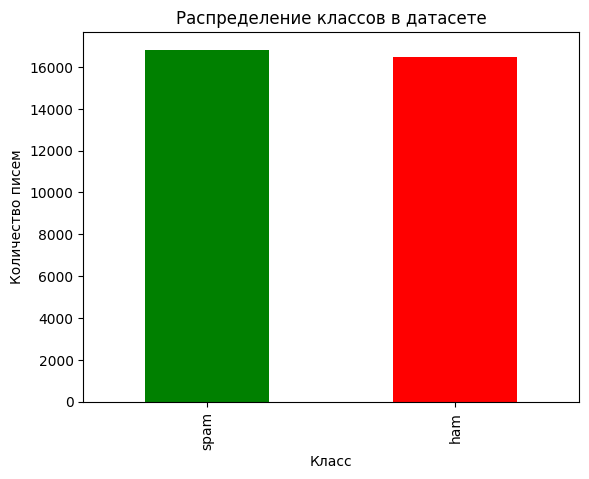

In [9]:
import matplotlib.pyplot as plt

data['Spam/Ham'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title("Распределение классов в датасете")
plt.xlabel("Класс")
plt.ylabel("Количество писем")
plt.show()

# Проверим результат

In [10]:
print("Пример после очистки:")
print(data[['Clear_Message', 'Spam/Ham']].head(), "\n")

print("Баланс классов:")
print(data['Spam/Ham'].value_counts(), "\n")

print("Пропуски после очистки:", data['Clear_Message'].isnull().sum())

Пример после очистки:
                                       Clear_Message Spam/Ham
1  gary production from the high island larger bl...      ham
2                   calpine daily gas nomination doc      ham
3  fyi see note below already done stella forward...      ham
4  fyi forwarded by lauri a allen hou ect on pm k...      ham
5  jackie since the inlet to river plant is shut ...      ham 

Баланс классов:
Spam/Ham
spam    16824
ham     16487
Name: count, dtype: int64 

Пропуски после очистки: 0


In [13]:
data['length'] = data['Clear_Message'].apply(len)
print(data['length'].describe())

count     33311.000000
mean       1297.115848
std        3883.129999
min           1.000000
25%         270.000000
50%         573.000000
75%        1301.000000
max      205199.000000
Name: length, dtype: float64


# Сохраняем очищенный датасет

In [11]:
data.to_csv("./data/emails_clean1.csv", index=False, encoding="utf-8")
print("Датасет сохранён в 'emails_clean.csv'")

Датасет сохранён в 'emails_clean.csv'
